In [3]:
from pathlib import Path
import sys
import pickle
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon
from hydrax.utils.files import get_data_path
from scipy.ndimage import uniform_filter1d  # Or use np.convolve



def rotmat(yaw: float) -> np.ndarray:
    c, s = math.cos(yaw), math.sin(yaw)
    return np.array([[c, -s],
                     [s,  c]])
    
def rectangle_corners(center_xy, width, height, yaw):
    cx, cy = center_xy
    R = rotmat(yaw)
    hw, hh = width / 2.0, height / 2.0
    local = np.array([
        [-hw, -hh],
        [ hw, -hh],
        [ hw,  hh],
        [-hw,  hh],
    ])
    world = (local @ R.T) + np.array([cx, cy])
    return world

def t_shape_polys(x, y, yaw, stem_w, stem_h, head_w, head_h):
    stem_center_local = np.array([0.0, -head_h / 2.0])
    head_center_local = np.array([0.0,  stem_h / 2.0])

    stem_center_world = (stem_center_local @ rotmat(yaw).T) + np.array([x, y]) + np.array([0.0425, 0.0])
    head_center_world = (head_center_local @ rotmat(yaw).T) + np.array([x, y]) + np.array([0.0425, 0.0])

    stem_poly = rectangle_corners(stem_center_world, stem_w, stem_h, yaw)
    head_poly = rectangle_corners(head_center_world, head_w, head_h, yaw)
    return stem_poly, head_poly

def plot_action_space(ax, xmin, xmax, ymin, ymax, show_grid=False, grid_dx=0.25):
    ax.add_patch(Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, linewidth=1.5))
    if show_grid and grid_dx > 0:
        xv = np.arange(math.ceil(xmin / grid_dx) * grid_dx, xmax + 1e-9, grid_dx)
        yv = np.arange(math.ceil(ymin / grid_dx) * grid_dx, ymax + 1e-9, grid_dx)
        for xx in xv:
            ax.plot([xx, xx], [ymin, ymax], linewidth=0.4)
        for yy in yv:
            ax.plot([xmin, xmax], [yy, yy], linewidth=0.4)

def draw_t(ax, x, y, yaw_deg, stem_w, stem_h, head_w, head_h,
           face_alpha=0.4, edge_width=0.0, facecolor=None, edgecolor=None, label=None):
    yaw = yaw_deg#math.radians(yaw_deg)
    stem_poly, head_poly = t_shape_polys(x, y, yaw, stem_w, stem_h, head_w, head_h)
    poly_kwargs = dict(closed=True, alpha=face_alpha)
    if facecolor is not None:
        poly_kwargs["facecolor"] = facecolor
    if edgecolor is not None:
        poly_kwargs["edgecolor"] = edgecolor

    stem_patch = Polygon(stem_poly, **poly_kwargs, linewidth=edge_width)
    head_patch = Polygon(head_poly, **poly_kwargs, linewidth=edge_width)
    ax.add_patch(stem_patch)
    ax.add_patch(head_patch)
    if label:
        ax.text(x, y, label, ha="center", va="center", fontsize=10)
    return np.vstack([stem_poly, head_poly])


def quat_to_yaw_manual(qx, qy, qz, qw):
    # Normalize
    norm = np.sqrt(qx**2 + qy**2 + qz**2 + qw**2)
    qw /= norm; qx /= norm; qy /= norm; qz /= norm
    
    sin_yaw_2 = 2 * (qw * qz + qx * qy)
    cos_yaw_2 = 1 - 2 * (qy**2 + qz**2)
    yaw = np.arctan2(sin_yaw_2, cos_yaw_2)
    return np.rad2deg(yaw)

def subsample_to_target(data, target_steps=300):
    """Uniformly subsample data to target_steps if longer."""
    if len(data) <= target_steps:
        return data
    indices = np.linspace(0, len(data) - 1, target_steps, dtype=int)
    return [data[i] for i in indices]

import seaborn as sns
import pandas as pd
sns.set(font_scale=1.7, rc={'font.size':17, 'font.family':'serif'})

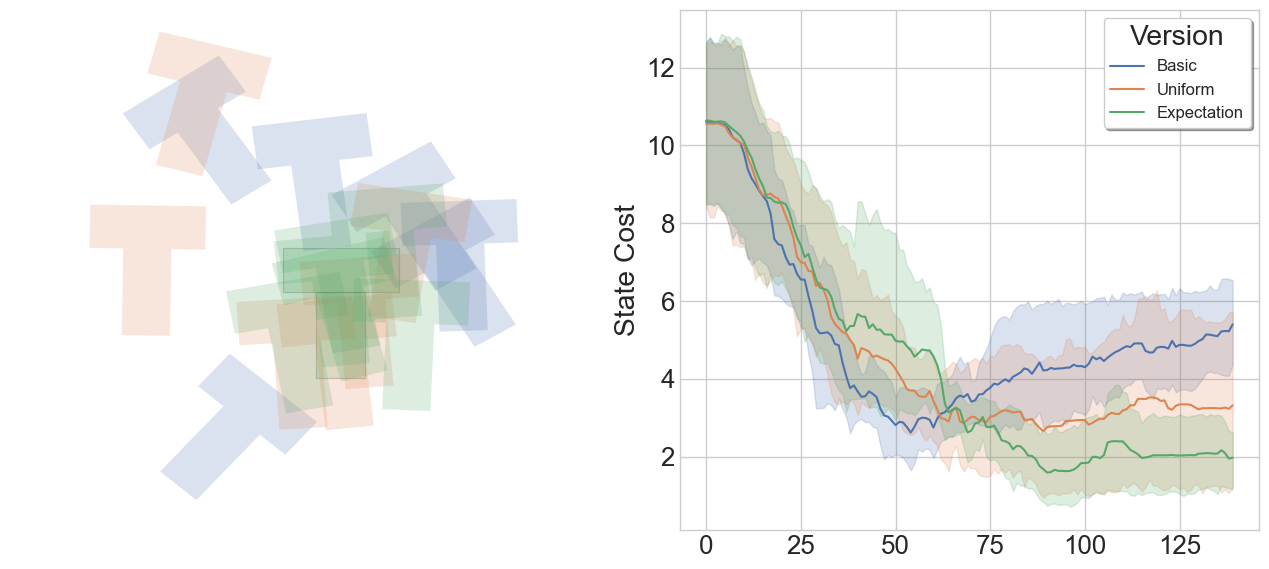

In [4]:
seeds = [100, 200, 300, 400, 500, 600]
# seeds = [100]

colors = ['C0', 'C1', 'C2']

# Collect all data into long-form DataFrame
df_list = []
final_T = {}
domain_weights = {}
distances = {}

for version in ["single", "uni", "exp"]:
    final_T[version] = []
    domain_weights[version] = {}
    distances[version] = {}
    for seed in seeds:
        path = get_data_path() / "sim-real-dr-robust" / f"fr3_dr_real_MTP_seed{seed}_{version}.pkl"
        # path = get_data_path() / "dr_real_margin_sweep" / f"fr3_dr_real_MTP_seed{seed}_{version}.pkl"
        
        with open(path, "rb") as f:
            data = pickle.load(f)
        
        data = subsample_to_target(data, target_steps=140)  
        
        # final T
        quat = np.array(data[-1]['object_quat'])
        # quat to yaw
        jaw = quat_to_yaw_manual(quat[3], quat[0], quat[1], quat[2])
        x = data[-1]['object_pos'][0]
        y = data[-1]['object_pos'][1]
        
        # account for moved goal
        if seed == 200:
            x += 0.05
            y -= 0.1
        elif seed == 300:
            x -= 0.1
            y -= 0.05
        elif seed == 400:
            x -= 0.05
            y += 0.1
        elif seed == 500:
            x += 0.05
        elif seed == 600:
            x += 0.0
            y -= 0.05
        final_T[version].append(np.concatenate((np.array([x, y]), np.array([jaw]))))
        domain_weights[version][seed] = [data[i]['domain_weights'] for i in range(len(data))]
        distances[version][seed] = [data[i]['distances'] for i in range(len(data))]
        timestep = np.arange(min(400, len(data)))
        df_list.append(pd.DataFrame({
            'timestep': timestep,
            'terminal_error': [d["terminal_error"] for d in data[:400]],
            'version': version,
            'seed': seed
        }))



plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
df = pd.concat(df_list)
final_Ts = np.array(final_T[version]) if version in final_T else np.array([])


# plot
draw_t(axes[0], 0.0, 0.5, 0.0, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
        face_alpha=0.2, edge_width=0.9, edgecolor='black', facecolor='C2')

# draw final Ts
for version, idx in zip(["single", "uni", "exp"], range(3), strict=True):
    Ts = np.array(final_T[version]) if version in final_T else np.array([])
    for i in range(Ts.shape[0]):
        x, y, yaw = Ts[i]
        yaw = yaw - np.pi/4 + np.pi/8 
        draw_t(axes[0], -y, x, yaw, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
            face_alpha=0.2, facecolor=colors[idx])
axes[0].set_xlim([-0.3, 0.3])
axes[0].set_ylim([0.25, 0.85])
# remove ticks
axes[0].set_xticks([])
axes[0].set_yticks([])
# remove border
for spine in axes[0].spines.values():
    spine.set_visible(False)

sns.lineplot(data=df, x='timestep', y='terminal_error', hue='version', ax=axes[1])
axes[1].set_xlabel("Planning Step")
axes[1].set_xlabel("")
axes[1].set_ylabel("State Cost")
handles, labels = axes[1].get_legend_handles_labels()
# Example mapping from old to new labels
mapping = {'single': 'Basic', 'uni': 'Uniform', 'exp': 'Expectation'}

new_labels = [mapping.get(l, l) for l in labels]
axes[1].legend(
    handles=handles,
    labels=new_labels,
    title="Version",
    loc='upper right',
    frameon=True,
    fancybox=True,
    shadow=True,
    ncol=1,
    fontsize=12
)
plt.tight_layout()
plt.show()
# save as pdf
fig.savefig(f"fr3_dr_robsutness.pdf", bbox_inches='tight')

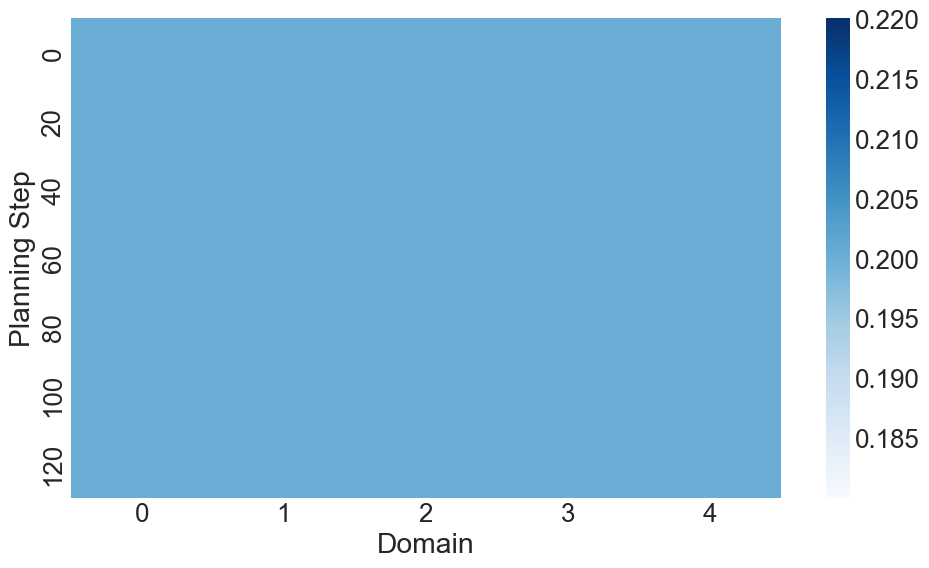

In [5]:

weights = domain_weights['exp'][100]  # shape (timesteps, domains)
weights = np.array(weights)[::20]  # subsample for better visualization

# heatmap table of domain weights over time
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(weights, ax=ax, cmap='Blues')
ax.set_xlabel('Domain')
ax.set_ylabel('Planning Step')
ax.set_yticklabels(np.arange(0, weights.shape[0]*20, 20))

plt.tight_layout()
plt.show()